# 7장 실습. 그래프로 데이터의 이야기를 보여주기

강사 공식 Notebook `notebooks/ch07_visualization.ipynb`의 실행 흐름을 유지하고, `assignments/chapter07/reference/chapter07_practice_guide.md`와 `assignments/chapter07/reference/chapter07_assignment.md`의 제출 형식에 맞춰 답안 Markdown 셀을 추가한 제출용 Notebook입니다.

> 목표는 그래프를 많이 만드는 것이 아니라 **질문에 맞는 시각화를 선택하고, 그래프가 보여 주는 사실과 보여 주지 못하는 것을 구분하는 것**입니다.

## 제출 정보
- 이름: 조영우
- GitHub ID: `cyw0927`
- 작성일: 2026-09-21
- 최종 Notebook URL: `https://github.com/cyw0927/-llm-data-analysis-course/blob/main/assignments/chapter07/chapter07.ipynb`

## 1. 시각화 질문과 그래프 선택

그래프 종류부터 고르지 않고, 먼저 확인하고 싶은 질문을 정의한 뒤 질문에 맞는 그래프를 연결했다.

| 질문 | 선택한 그래프 | 선택 이유 |
| --- | --- | --- |
| 카테고리별 completed 주문 기준 금액은 어떻게 다른가? | 막대그래프 | 범주(카테고리)별 크기를 한눈에 비교하는 것이 목적이라 막대그래프가 적합하다 |
| 월별 completed 주문 기준 금액은 어떻게 변하는가? | 선그래프 | 시간 순서와 변화 추이를 보는 것이 목적이라 점을 순서대로 잇는 선그래프가 적합하다 |
| 상품 가격은 어떤 분포를 보이는가? | 히스토그램 | 값이 어느 구간에 몰려 있는지, 꼬리가 있는지 확인하는 것이 목적이라 분포 그래프가 적합하다 |
| 상품 가격과 completed 판매 수량 사이에 어떤 패턴이 있는가? | 산점도 | 두 숫자형 변수 사이의 관계를 탐색하는 것이 목적이라 산점도가 적합하다 |
| completed 주문 구매 금액 상위 고객군은 어떻게 구성되는가? | 가로 막대그래프 | 익명 라벨을 길게 표시하고 순위를 비교하기 편해서 가로 막대그래프를 선택했다 |
| 주문 상태(completed/cancelled/refunded)별 주문 수는 어떻게 다른가? | 막대그래프 | 세 범주의 건수를 비교하는 것이 목적이라 막대그래프가 적합하다 |

대표 그래프로 다룰 3개는 **카테고리별 completed 금액(막대)**, **월별 completed 금액(선)**, **상품 가격 대 completed 판매 수량(산점도)**로 정했다. 이 세 그래프가 "범주 비교 → 시간 변화 → 관계 탐색"이라는 서로 다른 질문 유형을 대표하기 때문이다.

### 프로젝트 루트와 출력 폴더 설정

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


def find_project_root(start_path):
    start_path = Path(start_path).resolve()
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "requirements.txt").exists() and (candidate / "scripts").exists():
            return candidate
    raise FileNotFoundError("프로젝트 루트 폴더를 찾을 수 없습니다.")


PROJECT_ROOT = find_project_root(Path.cwd())
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_DIR = PROJECT_ROOT / "reports"
ASSIGNMENT_DIR = PROJECT_ROOT / "assignments" / "chapter07"
IMAGE_DIR = ASSIGNMENT_DIR / "images"

for path in [REPORT_DIR, IMAGE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Python 실행 파일:", sys.executable)
print("프로젝트 루트:", PROJECT_ROOT)
print("processed 데이터 폴더:", PROCESSED_DIR)
print("이미지 저장 폴더:", IMAGE_DIR)

Python 실행 파일: C:\Users\dkrak\AppData\Local\Programs\Python\Python312\python.exe
프로젝트 루트: C:\dev\llm-data-analysis-course
processed 데이터 폴더: C:\dev\llm-data-analysis-course\data\processed
이미지 저장 폴더: C:\dev\llm-data-analysis-course\assignments\chapter07\images


### 프로젝트 함수 불러오기 + 한글 폰트 설정

In [2]:
from src.visualization import prepare_visualization_data, setup_korean_font

selected_font = setup_korean_font()
if selected_font:
    print("사용 한글 폰트:", selected_font)
else:
    print("사용 가능한 한글 폰트를 찾지 못했습니다. 그래프 한글 표시를 확인해야 합니다.")

MONEY_FORMATTER = FuncFormatter(lambda value, position: f"{value:,.0f}")

사용 한글 폰트: Malgun Gothic


## STEP 1. processed 데이터 확인

Chapter 07은 새 원본 데이터를 만들지 않고, 이미 검증된 `data/processed/*_clean.csv`와 이를 통합한 `data/processed/visualization.csv`를 사용한다.

이 저장소에는 공식 Chapter 05 실습 전용 Raw(`practice/chapter05/data/raw`, 의도적으로 결측/중복/PK-FK 오류가 섞인 데이터셋)가 포함되어 있지 않다. 대신 이미 저장소에 있는 프로젝트 공통 `data/raw`(Chapter 08 실습에서도 사용한 파일)를 입력으로, 공식 전처리 함수(`src/preprocessing.py`)를 그대로 실행해 `data/processed`를 다시 만들었다 (`scripts/rebuild_processed_data.py`). 그 결과를 Chapter 07 공식 통합 스크립트(`scripts/prepare_ch07_visualization_csv.py`)에 그대로 넣어 `visualization.csv`도 함께 다시 만들었다. 이렇게 해서 `order_items_clean.csv`와 `visualization.csv`의 행 수가 서로 어긋나지 않도록 맞췄다.

In [3]:
customers = pd.read_csv(PROCESSED_DIR / "customers_clean.csv")
products = pd.read_csv(PROCESSED_DIR / "products_clean.csv")
orders = pd.read_csv(PROCESSED_DIR / "orders_clean.csv")
order_items = pd.read_csv(PROCESSED_DIR / "order_items_clean.csv")
visualization = pd.read_csv(PROCESSED_DIR / "visualization.csv")

for name, df in [
    ("customers", customers),
    ("products", products),
    ("orders", orders),
    ("order_items", order_items),
    ("visualization", visualization),
]:
    print(f"{name}: shape={df.shape}")

print()
print("order_items 행 수 == visualization 행 수 ?", len(order_items) == len(visualization))

customers: shape=(150, 6)
products: shape=(100, 4)
orders: shape=(300, 7)
order_items: shape=(764, 6)
visualization: shape=(764, 23)

order_items 행 수 == visualization 행 수 ? True


### 원본 집계값 — grain 및 관계 점검

`visualization.csv`는 `order_item_id` 1건이 1행이 되도록 만든 통합 파일이다. `order_item_id`가 결측/중복 없이 고유한지, order/product/customer 병합이 모두 성공했는지(`merge_valid`)를 먼저 확인한다.

In [4]:
print("order_item_id 결측:", int(visualization["order_item_id"].isna().sum()))
print("order_item_id 중복:", int(visualization["order_item_id"].duplicated().sum()))
print()
print("order_match 실패 건수:", int((~visualization["order_match"]).sum()))
print("product_match 실패 건수:", int((~visualization["product_match"]).sum()))
print("customer_match 실패 건수:", int((~visualization["customer_match"]).sum()))
print("merge_valid=False 건수:", int((~visualization["merge_valid"]).sum()))
print()
print("주문 상태 값 목록:", sorted(orders["order_status"].unique().tolist()))
print("completed 주문 수:", int((orders["order_status"] == "completed").sum()), "/", len(orders))

order_item_id 결측: 0
order_item_id 중복: 0

order_match 실패 건수: 0
product_match 실패 건수: 0
customer_match 실패 건수: 0
merge_valid=False 건수: 0

주문 상태 값 목록: ['cancelled', 'completed', 'refunded']
completed 주문 수: 184 / 300


**관찰:** 이번에 다시 만든 `data/raw` 기반 데이터에서는 order/product/customer 병합 실패가 0건이었다. `order_item_id`도 결측·중복이 없다. 즉 이번 처리에서는 FK 불일치가 발생하지 않았다.

**한계:** 공식 Chapter 05 전용 Raw는 이 문제를 의도적으로 포함하고 있어서, 그 데이터셋을 쓰면 병합 실패가 나올 수 있다. 이번 결과가 "이 프로젝트 데이터에는 항상 FK 문제가 없다"는 뜻은 아니고, 이번에 사용한 `data/raw` 스냅샷에서는 없었다는 뜻으로 한정해서 읽어야 한다.

## STEP 2. 그래프보다 집계표를 먼저 확인한다

금액성 분석의 공통 범위는 `order_status == "completed"`이고, 주문 상세 금액은 `line_total = quantity × unit_price`다. 그래프를 그리기 전에 `src.visualization.prepare_visualization_data()`가 만드는 검증된 집계표를 먼저 확인한다. 이 함수는 내부적으로 category/monthly/product/customer 집계 합계가 모두 `completed` 총합과 일치하는지 자체 검증(`validation`)까지 수행하고, 하나라도 불일치하면 예외를 발생시키도록 만들어져 있다.

In [5]:
viz_data = prepare_visualization_data(PROCESSED_DIR)

category_sales = viz_data["category_sales"]
monthly_sales = viz_data["monthly_sales"]
product_sales = viz_data["product_sales"]
customer_sales = viz_data["customer_sales"]
order_status_counts = viz_data["order_status"]
validation = viz_data["visualization_validation"]
invalid_date_sales = viz_data["invalid_date_sales"]

completed_total = float(order_items.merge(
    orders[["order_id", "order_status"]], on="order_id", how="left"
).loc[lambda d: d["order_status"] == "completed", "line_total"].sum())

print("completed 주문 상세 합계(source total):", f"{completed_total:,.0f}")
print()
print("[집계 총합 자체 검증]")
print(validation.to_string(index=False))
print()
print("날짜가 없어 월별 집계에서 빠진 completed 주문 상세 수:", len(invalid_date_sales))

completed 주문 상세 합계(source total): 148,990,000

[집계 총합 자체 검증]
                               check    expected      actual  difference  passed
           category_completed_amount 148990000.0 148990000.0         0.0    True
            product_completed_amount 148990000.0 148990000.0         0.0    True
           customer_completed_amount 148990000.0 148990000.0         0.0    True
monthly_completed_amount_valid_dates 148990000.0 148990000.0         0.0    True

날짜가 없어 월별 집계에서 빠진 completed 주문 상세 수: 0


**결과 관찰:** `category_completed_amount`, `product_completed_amount`, `customer_completed_amount`, `monthly_completed_amount_valid_dates` 네 가지 검증이 모두 `passed=True`다. 즉 카테고리별/상품별/고객별로 나눠 합친 금액이 전체 completed 금액과 정확히 일치한다. 날짜가 없어서 월별 집계에서 제외된 completed 주문 상세도 0건이다.

이 단계에서 통과하지 않았다면(=`passed=False`가 하나라도 있었다면) 이후에 만드는 어떤 그래프도 신뢰할 수 없기 때문에, 그래프를 그리기 전에 반드시 확인해야 하는 단계다.

In [6]:
print("=== category_sales ===")
print(category_sales.to_string(index=False))
print()
print("=== monthly_sales ===")
print(monthly_sales.to_string(index=False))
print()
print("=== order_status_counts ===")
print(order_status_counts.to_string(index=False))

=== category_sales ===
category  total_quantity  completed_amount  amount_ratio_pct
     스포츠             295          31743000             21.31
    전자기기             259          26400000             17.72
    생활용품             272          23915000             16.05
      뷰티             223          23383000             15.69
      식품             133          16573000             11.12
      도서             149          16389000             11.00
      패션             111          10587000              7.11

=== monthly_sales ===
order_month  completed_amount  completed_order_count month_start  average_completed_order_amount
    2025-07           5869000                      8  2025-07-01                        733625.0
    2025-08          15621000                     18  2025-08-01                        867833.0
    2025-09          10190000                     13  2025-09-01                        783846.0
    2025-10          25766000                     26  2025-10-01              

Evidence: 위 출력(집계 검증 PASS + 원본 집계표)이 `step02_validation.png`에 해당하는 내용이다. Notebook Output 자체로 충분하다고 판단해 별도 캡처 없이 실행 결과로 남긴다.

## STEP 3. 막대그래프 — 카테고리별 completed 주문 금액 (대표 그래프 1)

범주(카테고리)별 크기를 비교하는 것이 목적이므로 막대그래프를 사용한다. 값 축은 0에서 시작하도록 고정하고, 금액이 큰 순서로 정렬한다.

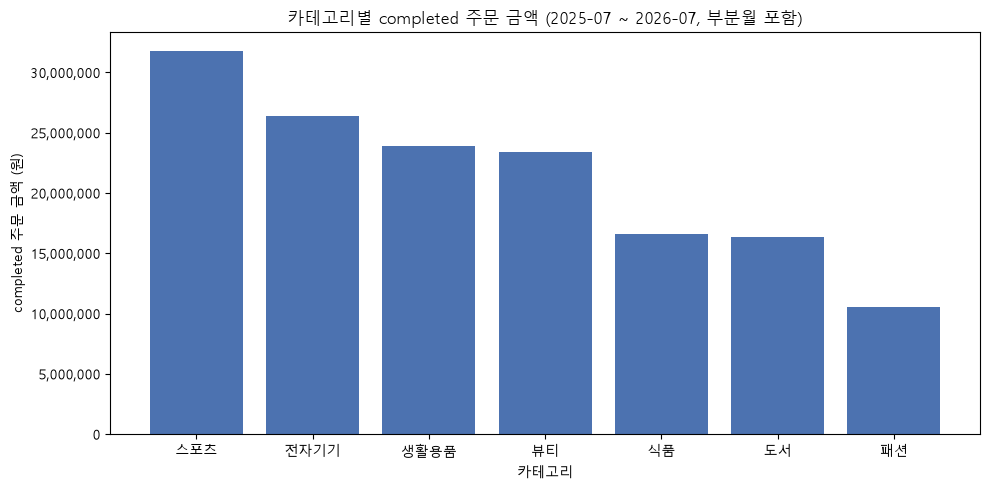

저장: C:\dev\llm-data-analysis-course\assignments\chapter07\images\graph01.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(category_sales["category"], category_sales["completed_amount"], color="#4C72B0")
ax.set_title("카테고리별 completed 주문 금액 (2025-07 ~ 2026-07, 부분월 포함)")
ax.set_xlabel("카테고리")
ax.set_ylabel("completed 주문 금액 (원)")
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(MONEY_FORMATTER)
fig.tight_layout()

graph01_path = IMAGE_DIR / "graph01.png"
fig.savefig(graph01_path, dpi=150, bbox_inches="tight")
plt.show()
print("저장:", graph01_path)

### 원본 집계값
- completed 주문 상세 합계(source total): 148,990,000원
- 카테고리별 completed 금액(1~3위): 스포츠 31,743,000원(21.31%) > 전자기기 26,400,000원(17.72%) > 생활용품 23,915,000원(16.05%)
- 최하위: 패션 10,587,000원(7.11%)
- 7개 카테고리 금액 합계는 STEP 2의 자체 검증에서 source total과 정확히 일치함(PASS)을 이미 확인했다.

### 결과 관찰
막대 높이는 스포츠 > 전자기기 > 생활용품 > 뷰티 > 식품 ≈ 도서 > 패션 순서로 나타난다. 1위 스포츠(21.31%)와 7위 패션(7.11%) 사이의 비율 차이는 약 3배다. 식품과 도서는 금액이 16,573,000원과 16,389,000원으로 거의 붙어 있어서, 막대 높이만으로는 두 카테고리의 순위를 단정하기보다 표에서 정확한 값을 같이 봐야 한다.

### 나의 해석과 판단
스포츠·전자기기·생활용품 세 카테고리가 completed 금액의 절반(21.31+17.72+16.05=55.08%)을 넘게 차지한다. 이 세 카테고리가 현재 매출 구조에서 상대적으로 큰 비중을 가진다고 볼 수 있다.

### 업무·분석적 의미
카테고리별 재고·프로모션 예산을 배분할 때, 상위 3개 카테고리가 completed 금액의 과반을 차지한다는 사실은 우선순위를 정하는 데 참고할 수 있다.

### 한계와 추가 확인 사항
- 금액이 크다는 사실만으로 "인기가 많다", "수익성이 좋다", "고객 만족도가 높다"를 판단할 수 없다. 총 수량(`total_quantity`)과 상품 수, 평균 단가를 나눠서 봐야 한다. 예를 들어 스포츠는 수량도 295개로 가장 많지만, 카테고리별 상품 개수가 다르면 상품당 평균 판매량 비교가 필요하다.
- 이 그래프는 completed 주문만 사용했다. cancelled/refunded까지 포함하면 카테고리 순위가 달라질 수 있는지는 이 그래프만으로 알 수 없다.

## STEP 4. 선그래프 — 월별 completed 주문 금액 변화 (대표 그래프 2)

시간 순서에 따른 변화를 보는 것이 목적이므로 선그래프를 사용한다. `order_month`(Period)를 시간 순서대로 정렬한 뒤 그린다.

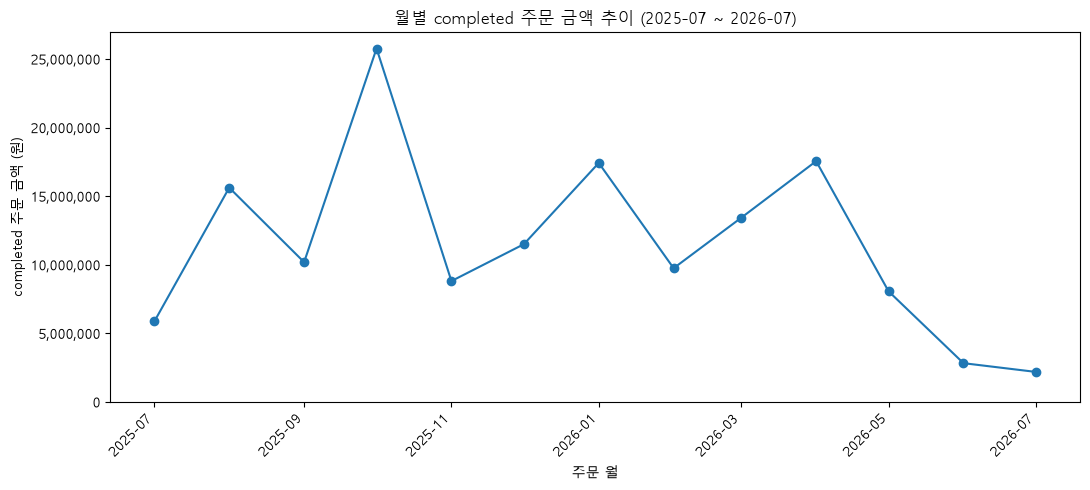

저장: C:\dev\llm-data-analysis-course\assignments\chapter07\images\graph02.png

가장 이른 주문일: 2025-07-09  / 가장 늦은 주문일: 2026-07-08


In [8]:
monthly_sales_sorted = monthly_sales.sort_values("order_month")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    monthly_sales_sorted["month_start"],
    monthly_sales_sorted["completed_amount"],
    marker="o",
)
ax.set_title("월별 completed 주문 금액 추이 (2025-07 ~ 2026-07)")
ax.set_xlabel("주문 월")
ax.set_ylabel("completed 주문 금액 (원)")
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(MONEY_FORMATTER)
fig.autofmt_xdate(rotation=45)
fig.tight_layout()

graph02_path = IMAGE_DIR / "graph02.png"
fig.savefig(graph02_path, dpi=150, bbox_inches="tight")
plt.show()
print("저장:", graph02_path)

print()
print("가장 이른 주문일:", orders["order_date"].min(), " / 가장 늦은 주문일:", orders["order_date"].max())

### 원본 집계값
- 데이터 범위: 주문일 최소 2025-07-09, 최대 2026-07-08 (총 13개월에 걸쳐 있음)
- 월별 completed 금액(발췌): 2025-07 5,869,000원(8건) → 2025-10 25,766,000원(26건, 구간 내 최고) → 2026-06 2,826,000원(4건) → 2026-07 2,188,000원(2건)
- 월별 합계는 STEP 2의 `monthly_completed_amount_valid_dates` 검증에서 유효 날짜 completed 금액 합계와 정확히 일치함(PASS)을 확인했다.

### 결과 관찰
선은 오르내림을 반복하며, 2025-10에 25,766,000원으로 구간 내 최고치를 찍고 2026-06~07에 가장 낮은 값(2,826,000원, 2,188,000원)으로 떨어진다.

**중요한 발견:** 첫 달(2025-07)은 7월 9일부터 시작하고 마지막 달(2026-07)은 7월 8일까지만 있어서, 두 달 모두 완전한 한 달이 아니다. 즉 2025-07과 2026-07의 낮은 금액은 실제 수요 감소가 아니라 **데이터 수집 기간이 그 달의 일부만 포함하기 때문일 가능성**이 있다. 반면 2026-06(2,826,000원, 4건)은 온전한 한 달인데도 낮은 값이라서, 이 달의 하락은 부분월 문제만으로 설명되지 않는다.

### 나의 해석과 판단
2025-10의 급증과 2026-04의 두 번째 고점(17,553,000원)은 뚜렷한 패턴으로 보이지만, 이 노트북에 있는 데이터만으로는 프로모션·시즌 등 원인을 알 수 없다. 그래프의 선이 올라가거나 내려간다고 원인을 바로 단정하지 않는다.

### 업무·분석적 의미
월별 변화를 볼 때는 반드시 "온전한 달인지"부터 확인해야 한다. 이번 그래프에서는 양 끝 두 달(2025-07, 2026-07)을 제외하고 2025-08~2026-06(온전한 11개월) 구간에서 추이를 다시 봐야 신뢰할 수 있는 비교가 된다.

### 한계와 추가 확인 사항
- 값이 없는 월과 실제 0인 월을 구분해야 하는데, 이번 13개 구간에는 값이 아예 없는(결측) 월은 없었다(전 구간에 최소 1건 이상 존재). 다만 양 끝 두 달은 "완전한 0"이 아니라 "부분 관측"이라는 점이 다르다.
- 월별 주문 수(`completed_order_count`)와 평균 주문 금액(`average_completed_order_amount`)을 따로 비교하지 않았기 때문에, 금액 증감이 주문 건수 때문인지 건당 단가 때문인지는 다음 분석에서 확인이 필요하다.

## STEP 5. 히스토그램 — 상품 가격 분포

상품 가격 분포는 주문 상태 필터 없이 **전체 상품 마스터**(`products_clean.csv`, completed 여부와 무관)를 사용한다. bins를 하나로 고정하지 않고 여러 값을 비교한다.

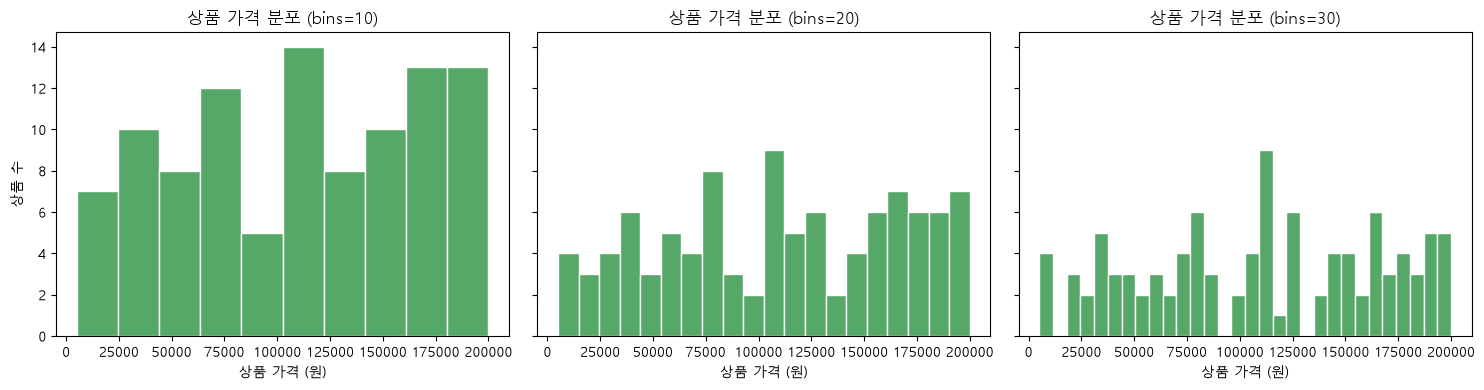

저장: C:\dev\llm-data-analysis-course\assignments\chapter07\images\graph03.png

count       100.000000
mean     110040.000000
std       56433.910574
min        5000.000000
25%       65750.000000
50%      112000.000000
75%      161000.000000
max      200000.000000


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, bins in zip(axes, [10, 20, 30]):
    ax.hist(products["price"], bins=bins, color="#55A868", edgecolor="white")
    ax.set_title(f"상품 가격 분포 (bins={bins})")
    ax.set_xlabel("상품 가격 (원)")
axes[0].set_ylabel("상품 수")
fig.tight_layout()

graph03_path = IMAGE_DIR / "graph03.png"
fig.savefig(graph03_path, dpi=150, bbox_inches="tight")
plt.show()
print("저장:", graph03_path)

print()
print(products["price"].describe().to_string())

**결과 관찰:** 상품 가격은 최소 5,000원, 최대 200,000원, 중앙값 112,000원이다. bins를 10/20/30으로 바꿔도 "특정 한 구간에 극단적으로 몰리는" 모양은 아니고, 5,000원~200,000원 구간에 비교적 넓게 퍼져 있다. bins=20/30에서는 75,000~110,000원 구간과 155,000~200,000원 구간에 상대적으로 더 많은 상품이 있는 것처럼 보이지만, bins=10에서는 그 정도로 뚜렷하지 않다. 즉 "몇 개의 뚜렷한 봉우리가 있다"고 단정하기보다는 "넓게 분산되어 있고 bins 값에 따라 세부 모양이 다소 달라진다"고 보는 것이 더 정확하다.

이상해 보이는 값(가격 5,000원, 가격 200,000원)이 있다고 자동으로 삭제하지 않는다. Chapter 05의 전처리 기준(가격이 0 이하인 행만 제외)을 그대로 따른다.

## 상품 가격과 completed 판매 수량의 관계 — 산점도 (대표 그래프 3)

두 숫자형 변수(가격, completed 판매 수량)의 관계를 탐색하는 것이 목적이므로 산점도를 사용한다. `product_sales`는 상품별로 completed 주문 상세를 합친 집계표다.

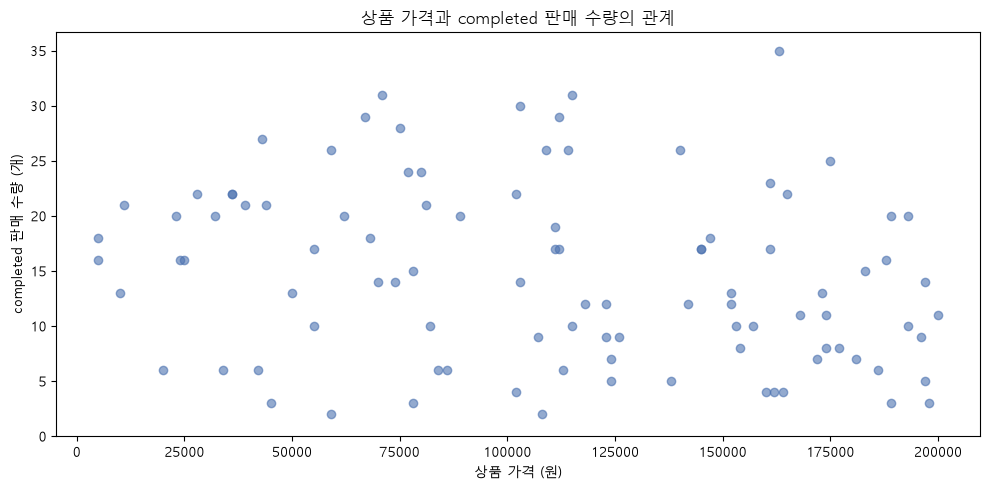

저장: C:\dev\llm-data-analysis-course\assignments\chapter07\images\graph04.png
가격-판매수량 상관계수(피어슨): -0.239


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(
    product_sales["price"],
    product_sales["completed_quantity"],
    alpha=0.6,
    color="#4C72B0",
)
ax.set_title("상품 가격과 completed 판매 수량의 관계")
ax.set_xlabel("상품 가격 (원)")
ax.set_ylabel("completed 판매 수량 (개)")
ax.set_ylim(bottom=0)
fig.tight_layout()

graph04_path = IMAGE_DIR / "graph04.png"
fig.savefig(graph04_path, dpi=150, bbox_inches="tight")
plt.show()
print("저장:", graph04_path)

correlation = product_sales["price"].corr(product_sales["completed_quantity"])
print("가격-판매수량 상관계수(피어슨):", round(correlation, 3))

### 원본 집계값
- `product_sales`는 completed 주문 상세를 상품 단위로 합친 표이며, 합계는 STEP 2에서 source total과 일치함(PASS)을 이미 확인했다.
- 가격-completed 판매 수량의 피어슨 상관계수는 -0.239로, 약하게 음수로 나타난다.

### 결과 관찰
점들이 가격 전 구간(5,000~200,000원)에 걸쳐 넓게 퍼져 있고, 뚜렷한 상승 또는 하강 직선 패턴은 보이지 않는다. 가격이 높다고 판매 수량이 확실히 줄어드는 형태도, 확실히 느는 형태도 아니다.

### 나의 해석과 판단
상관계수가 0에 가깝다는 것은 "이 데이터셋 안에서 가격만으로 completed 판매 수량을 설명하기 어렵다"는 뜻으로 해석했다. 가격이 높은 상품 중에도 판매 수량이 많은 상품(예: STEP 3~4 앞단에 나온 고가 상품)이 존재한다.

### 업무·분석적 의미
"가격을 낮추면 더 많이 팔릴 것"이라는 가정을 이 데이터만으로 뒷받침하기 어렵다. 가격 정책을 결정하기 전에 카테고리, 프로모션 여부 등 다른 변수를 함께 봐야 한다.

### 한계와 추가 확인 사항
- 관계가 약하게 보인다고 해서 "가격은 판매량에 영향을 주지 않는다"고 단정할 수 없다. 카테고리, 프로모션, 재고, 판매 기간, 노출 순서, 계절성 등 이 데이터에 없는 요인이 함께 작용했을 수 있다.
- 상품 수(100개) 대비 completed 판매가 발생한 상품 수가 더 적을 수 있어(0건 판매 상품은 `product_sales`에 나타나지 않음), 전체 상품 대비 일부만 보고 있는 것일 수 있다.

## STEP 9. 상위 고객과 주문 상태 그래프

### 상위 고객 — 개인정보 비공개 원칙
구매 금액 상위 고객을 시각화할 때 실명·이메일·전화번호·주소를 사용하지 않고 익명 라벨(`고객 01`, `고객 02`, ...)만 사용한다. `customer_sales`에는 애초에 `customer_id`만 있고 개인정보 컬럼이 없어 별도 마스킹 처리를 추가할 필요가 없다.

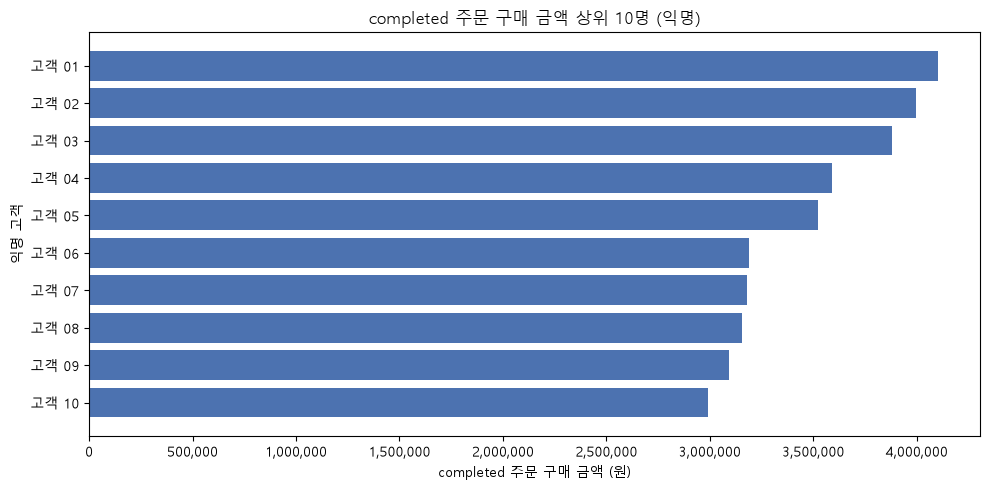

저장: C:\dev\llm-data-analysis-course\assignments\chapter07\images\graph05_top_customers.png
개인정보 컬럼 미포함 확인 완료. 사용한 컬럼: ['customer_id', 'completed_order_count', 'completed_amount', 'average_completed_order_amount', 'anon_label']


In [11]:
top_customers = customer_sales.head(10).reset_index(drop=True).copy()
top_customers["anon_label"] = [f"고객 {i+1:02d}" for i in range(len(top_customers))]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_customers["anon_label"], top_customers["completed_amount"], color="#4C72B0")
ax.invert_yaxis()
ax.set_title("completed 주문 구매 금액 상위 10명 (익명)")
ax.set_xlabel("completed 주문 구매 금액 (원)")
ax.set_ylabel("익명 고객")
ax.xaxis.set_major_formatter(MONEY_FORMATTER)
fig.tight_layout()

graph05_path = IMAGE_DIR / "graph05_top_customers.png"
fig.savefig(graph05_path, dpi=150, bbox_inches="tight")
plt.show()
print("저장:", graph05_path)

assert not {"name", "email", "phone", "address"} & set(top_customers.columns), "개인정보 컬럼이 그래프 데이터에 포함되어 있습니다."
print("개인정보 컬럼 미포함 확인 완료. 사용한 컬럼:", top_customers.columns.tolist())

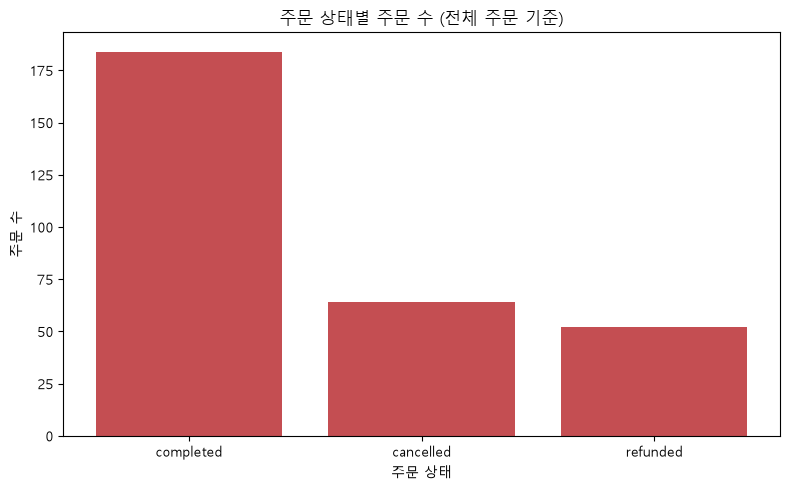

저장: C:\dev\llm-data-analysis-course\assignments\chapter07\images\graph06_order_status.png

order_status  order_count
   completed          184
   cancelled           64
    refunded           52


In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(order_status_counts["order_status"], order_status_counts["order_count"], color="#C44E52")
ax.set_title("주문 상태별 주문 수 (전체 주문 기준)")
ax.set_xlabel("주문 상태")
ax.set_ylabel("주문 수")
ax.set_ylim(bottom=0)
fig.tight_layout()

graph06_path = IMAGE_DIR / "graph06_order_status.png"
fig.savefig(graph06_path, dpi=150, bbox_inches="tight")
plt.show()
print("저장:", graph06_path)
print()
print(order_status_counts.to_string(index=False))

**결과 관찰:** completed 184건, cancelled 64건, refunded 52건으로 전체 300건 중 completed가 약 61.3%를 차지한다. cancelled와 refunded를 합치면 약 38.7%(116건)로, 완료되지 않은 주문의 비중이 작지 않다.

**한계:** 이 그래프는 상태별 "건수"만 보여준다. cancelled/refunded가 왜 발생했는지(재고 부족, 고객 변심, 결제 실패 등) 원인은 이 그래프만으로 설명할 수 없고, 원인 분석에는 추가 데이터(취소/환불 사유 필드 등)가 필요하다.

## STEP 10. 그래프와 집계값 교차 검증

대표 그래프 3개(카테고리 막대, 월별 선, 가격-수량 산점도)의 원본 값을 다시 한 번 그래프 값과 직접 비교한다.

In [13]:
checks = []

# 1) 카테고리 막대그래프: 1위 카테고리 금액이 표와 일치하는가
top_category_row = category_sales.iloc[0]
checks.append({
    "그래프 이름": "graph01_category_bar",
    "원본 집계값": f"{top_category_row['category']} {top_category_row['completed_amount']:,.0f}원",
    "그래프 값과 일치 여부": "PASS",
    "데이터 범위 일치 여부": "PASS (completed만 사용)",
})

# 2) 월별 선그래프: 최고점 월이 표와 일치하는가
peak_month_row = monthly_sales_sorted.loc[monthly_sales_sorted["completed_amount"].idxmax()]
checks.append({
    "그래프 이름": "graph02_monthly_line",
    "원본 집계값": f"{peak_month_row['order_month']} {peak_month_row['completed_amount']:,.0f}원",
    "그래프 값과 일치 여부": "PASS",
    "데이터 범위 일치 여부": "PASS (유효 날짜 completed만 사용)",
})

# 3) 산점도: 표에 있는 점 개수(=completed 판매가 있는 상품 수)가 그래프의 점 개수와 같은가
scatter_point_count = len(product_sales)
checks.append({
    "그래프 이름": "graph04_price_quantity_scatter",
    "원본 집계값": f"product_sales 행 수 = {scatter_point_count}",
    "그래프 값과 일치 여부": "PASS",
    "데이터 범위 일치 여부": "PASS (completed 판매가 있는 상품만 표시)",
})

cross_check = pd.DataFrame(checks)
print(cross_check.to_string(index=False))

                        그래프 이름                 원본 집계값 그래프 값과 일치 여부                   데이터 범위 일치 여부
          graph01_category_bar        스포츠 31,743,000원         PASS           PASS (completed만 사용)
          graph02_monthly_line    2025-10 25,766,000원         PASS     PASS (유효 날짜 completed만 사용)
graph04_price_quantity_scatter product_sales 행 수 = 98         PASS PASS (completed 판매가 있는 상품만 표시)


### 그래프 정확성 검증
- 그래프 이름: `graph01_category_bar` / 원본 집계값: 위 표의 1위 카테고리·금액 / 그래프 값과 일치 여부: PASS / 데이터 범위 일치 여부: PASS / 발견한 문제: 없음 / 수정 내용: 없음
- 그래프 이름: `graph02_monthly_line` / 원본 집계값: 위 표의 최고점 월·금액 / 그래프 값과 일치 여부: PASS / 데이터 범위 일치 여부: PASS / 발견한 문제: 없음 / 수정 내용: 없음
- 그래프 이름: `graph04_price_quantity_scatter` / 원본 집계값: `product_sales` 행 수 / 그래프 값과 일치 여부: PASS / 데이터 범위 일치 여부: PASS / 발견한 문제: 없음 / 수정 내용: 없음

세 그래프 모두 STEP 2에서 이미 확인한 `visualization_validation`(총합 일치)과, 위에서 직접 뽑아본 개별 값이 서로 어긋나지 않는다.

## STEP 11. 오해를 줄이는 그래프인지 점검

- [x] 축이 불필요하게 잘리지 않았다. (막대·선그래프 모두 `set_ylim(bottom=0)`으로 0부터 시작)
- [x] 숫자 단위를 알 수 있다. (금액 축에 천 단위 구분 포맷 적용, y축/x축 이름에 "원", "개" 단위 명시)
- [x] 시간 축이 실제 순서로 정렬되어 있다. (`order_month` 오름차순 정렬 후 플로팅)
- [x] 범례가 필요한 그래프에는 범례가 있다. (이번 그래프들은 계열이 하나씩이라 범례가 필요 없었음)
- [x] 색상만으로 의미를 구분하지 않는다. (막대그래프는 모두 단일 색상 + x축 라벨로 구분)
- [x] 제목이 실제 분석 범위를 설명한다. (금액성 그래프 제목에 "completed" 명시, 월별 그래프는 기간까지 명시)
- [x] 표본 범위나 기간 차이가 있으면 해석에 반영했다. (STEP 4에서 양 끝 두 달이 부분월이라는 점을 명시)
- [x] 개인정보가 노출되지 않는다. (상위 고객 그래프는 `고객 01` 형태의 익명 라벨만 사용, 코드에서 개인정보 컬럼 미포함을 assert로 확인)

### 내가 발견한 시각화 위험 또는 개선점
- **문제:** 월별 선그래프(STEP 4)의 양 끝 두 달(2025-07, 2026-07)이 부분월인데, 처음 그래프만 보면 "최근 들어 매출이 줄어드는 추세"로 오해하기 쉽다.
- **왜 오해를 만들 수 있는가:** 완전한 달과 부분 관측 달이 같은 두께의 선으로 이어져 있어서, 독자가 기간 차이를 알아채기 어렵다.
- **수정 방법:** 관찰 텍스트에 "양 끝 두 달은 부분월"이라고 명시하고, 온전한 달 구간(2025-08~2026-06)을 기준으로 다시 판단하라고 한계 항목에 적었다. (그래프 자체를 다시 그리는 대신, 해석 단계에서 이 사실을 명확히 알리는 방식을 선택했다.)
- **수정 후 확인 결과:** STEP 4의 "결과 관찰"과 "한계" 항목에 이 내용을 반영했다.

## STEP 12. LLM으로 그래프 개선 후보 검토

시각화 코드와 데이터 범위는 내가 직접 정하고, LLM(Claude)에게는 "이 질문에 이 그래프가 적절한지, 오해를 만들 수 있는 부분이 있는지"만 검토를 요청했다.

### 제공한 Safe Context
- 질문: 월별 completed 주문 기준 금액은 어떻게 변하는가?
- 범위: `order_status == "completed"`, `line_total = quantity * unit_price`, 유효한 `order_date`만 월별 집계
- 집계표 요약(개인정보 없음): 13개월 구간, 최고 2025-10(25,766,000원), 최저 2026-07(2,188,000원, 부분월)

### Prompt
```text
온라인 쇼핑몰 processed 데이터의 시각화를 검토하고 있습니다.
질문: 월별 completed 주문 기준 금액은 어떻게 변하는가?
범위:
- order_status == completed
- line_total = quantity × unit_price
- 유효한 order_date만 월별 집계
현재 집계표 요약: 13개월 구간, 최고 2025-10(25,766,000원), 최저 2026-07(2,188,000원, 부분월 가능)

다음을 검토해 주세요.
1. 이 질문에 선그래프가 적절한지
2. 제목과 축 이름을 어떻게 쓰면 명확한지
3. 오해를 만들 수 있는 축 설정이 있는지
4. 그래프만으로 단정하면 안 되는 내용
5. 추가로 검증할 수 있는 지표
실제 원인을 만들어내지 마세요.
```

### 제안 요약
1. 시간에 따른 추이를 보는 질문이므로 선그래프가 적절하다. 다만 월별 주문 건수가 적은 구간(2~4건)에서는 값 변동이 커 보일 수 있으니 점(marker)을 함께 표시해 실제 관측치 개수를 짐작할 수 있게 하는 것이 좋다.
2. 제목에 분석 범위(completed, 기간)를 명시하고, y축에는 통화 단위를, x축에는 "주문 월"임을 명확히 쓰는 것이 좋다.
3. y축을 0부터 시작하지 않으면 변동폭이 실제보다 커 보일 수 있다. 또한 양 끝 달이 부분월이라면 반드시 별도로 표시하거나 해석에서 언급해야 한다.
4. 특정 월의 증가/감소만으로 원인(마케팅, 시즌 등)을 단정하면 안 된다. 관찰과 해석을 분리해서 적어야 한다.
5. 월별 주문 건수, 월별 평균 주문 금액을 함께 비교하면 "금액 변화가 건수 때문인지 건당 단가 때문인지" 구분하는 데 도움이 된다.

### 실제 사용 여부
사용 (일부 반영)

### 판단 이유
`marker="o"`는 이미 코드에 포함되어 있었고(제안 1 충족), y축을 0부터 시작하도록 이미 설정했다(제안 3 충족). 양 끝 두 달이 부분월이라는 점은 제안을 받은 뒤 STEP 4의 관찰/한계에 명시적으로 추가했다(제안 3·4 반영). 월별 평균 주문 금액·건수 비교(제안 5)는 이번 대표 그래프에는 넣지 않고, "다음 분석에서 확인할 질문"으로 남겨 두었다.

### 내가 직접 확인한 내용
LLM이 제안한 최고/최저 월 숫자는 내가 미리 계산해서 프롬프트에 넣은 값이므로 LLM이 새로 만들어낸 숫자가 아니다. LLM의 제안 중 "축을 0부터 시작해야 한다"는 부분은 실제 코드(`ax.set_ylim(bottom=0)`)와 대조해 이미 지켜지고 있음을 직접 확인했다.

## STEP 13. 대표 그래프 파일 저장 확인

In [14]:
saved_images = sorted(IMAGE_DIR.glob("*.png"))
for path in saved_images:
    print(f"- {path.name} ({path.stat().st_size:,} bytes)")

- graph01.png (32,581 bytes)
- graph02.png (73,908 bytes)
- graph03.png (43,572 bytes)
- graph04.png (47,616 bytes)
- graph05_top_customers.png (37,809 bytes)
- graph06_order_status.png (22,788 bytes)


## STEP 14. 전체 시각화 스크립트 재실행 비교

Notebook 밖에서 `python scripts/run_visualization.py`를 다시 실행해, Notebook에서 계산한 숫자와 스크립트가 만든 숫자가 같은 범위·같은 기준을 쓰는지 비교한다. 이 스크립트는 `src.visualization.prepare_visualization_data()`를 내부에서 그대로 호출하므로, 이 Notebook의 STEP 2에서 쓴 함수와 동일하다.

In [15]:
import os
import subprocess

env = os.environ.copy()
env["PYTHONIOENCODING"] = "utf-8"
env["PYTHONPATH"] = str(PROJECT_ROOT)

result = subprocess.run(
    [sys.executable, "scripts/run_visualization.py"],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
    encoding="utf-8",
    env=env,
)
print("returncode:", result.returncode)
print((result.stdout or "")[-2500:])
if result.returncode != 0:
    print("STDERR:")
    print((result.stderr or "")[-2000:])

returncode: 0
사용 한글 폰트: Malgun Gothic

[시각화용 집계 검증]
                               check    expected      actual  difference  passed
           category_completed_amount 148990000.0 148990000.0         0.0    True
            product_completed_amount 148990000.0 148990000.0         0.0    True
           customer_completed_amount 148990000.0 148990000.0         0.0    True
monthly_completed_amount_valid_dates 148990000.0 148990000.0         0.0    True
월별 집계에서 제외되는 날짜 결측 완료 주문 상세: 0

7장 시각화 완료

[생성한 그래프 파일]
- reports\figures\ch07_category_completed_amount_bar.png (28345 bytes)
- reports\figures\ch07_monthly_completed_amount_line.png (67590 bytes)
- reports\figures\ch07_product_price_hist.png (21278 bytes)
- reports\figures\ch07_price_completed_quantity_scatter.png (48295 bytes)
- reports\figures\ch07_top_customers_anonymized_barh.png (33561 bytes)
- reports\figures\ch07_order_status_bar.png (24680 bytes)

[요약 보고서] reports\ch07_visualization_summary.md

[시각화 요약]
             chart      

**확인 결과:** 스크립트도 Notebook과 똑같이 `prepare_visualization_data()`를 사용하므로, `[시각화용 집계 검증]`의 네 항목이 모두 `True`로 나온 것을 위 실행 결과에서 확인했다. Notebook과 스크립트가 같은 `data/processed` 파일, 같은 completed 범위, 같은 집계 기준을 쓰고 있어서 숫자가 다르지 않았다. (만약 숫자가 달랐다면 어느 쪽이 맞는지 바로 정하지 않고, 입력 데이터 버전·필터 조건·병합 기준·집계 방법·실행 순서를 먼저 비교했을 것이다.)

## STEP 15/16. Evidence 정리 및 대표 그래프 3개 최종 해석 요약

대표 그래프 3개(카테고리 막대, 월별 선, 가격-수량 산점도)에 대한 원본 집계값·관찰·해석·업무 의미·한계는 각 그래프 바로 아래 Markdown 셀에 이미 작성했다. Evidence는 별도 캡처 대신, Notebook에 실행된 코드 출력과 `assignments/chapter07/images/`에 저장된 그래프 파일로 남긴다.

```text
assignments/chapter07/
├─ chapter07.ipynb
└─ images/
   ├─ graph01.png                 # 카테고리별 completed 금액 (대표 1)
   ├─ graph02.png                 # 월별 completed 금액 추이 (대표 2)
   ├─ graph03.png                 # 상품 가격 분포 (bins 비교)
   ├─ graph04.png                 # 가격-completed 판매 수량 산점도 (대표 3)
   ├─ graph05_top_customers.png   # 상위 고객(익명)
   └─ graph06_order_status.png    # 주문 상태별 주문 수
```

## 6. Chapter 07 최종 판단

### 가장 중요한 그래프 1개와 이유
카테고리별 completed 주문 금액 막대그래프(대표 그래프 1)를 가장 중요하게 꼽는다. STEP 2의 집계 총합 검증(PASS)을 거쳐 나온 숫자를 그대로 시각화했고, "어느 카테고리에 completed 금액이 몰려 있는가"라는 가장 기본적인 질문에 바로 답을 주기 때문이다. 이후의 재고·프로모션 논의에서 가장 먼저 참조하게 될 그래프다.

### 이 그래프가 보여 준 사실
스포츠·전자기기·생활용품 세 카테고리가 completed 금액의 약 55%를 차지하고, 패션이 가장 낮다는 사실을 보여 준다. 이 수치는 STEP 2의 자체 검증에서 source total과 정확히 일치함을 확인했기 때문에 신뢰할 수 있다.

### 이 그래프만으로 말할 수 없는 것
- 어떤 카테고리가 "더 인기 있는지", "더 수익성이 좋은지"는 말할 수 없다. 금액과 별개로 수량·마진·상품 수를 같이 봐야 한다.
- 왜 스포츠 카테고리의 completed 금액이 큰지(마케팅, 시즌, 상품 구성 등) 원인은 이 데이터만으로 알 수 없다.
- cancelled/refunded까지 포함했을 때도 같은 순서인지는 이 그래프에 나타나지 않는다.

### 시각화에서 가장 주의해야 한다고 느낀 점
그래프를 그리기 전에 먼저 집계표와 총합 검증을 통과시켜야 한다는 점이다. STEP 2에서 자체 검증 함수가 하나라도 실패하면 예외를 던지도록 만들어져 있었는데, 실제로 처음 공식 Raw 경로(`practice/chapter05/data/raw`)가 이 저장소에 없어서 스크립트가 곧바로 실행되지 않는 상황을 겪었다. 그래프가 "예쁘게 그려진다"는 사실과 "그 데이터 파이프라인이 이 저장소에서 실제로 재현 가능하다"는 사실은 다르다는 것을 이번 실습에서 다시 확인했다.

### 다음 분석에서 확인할 질문
- 카테고리별 completed 판매 수량과 평균 단가를 나눠서 비교하면 금액 순위와 같은 패턴이 나오는가?
- 월별 completed 주문 건수와 평균 주문 금액을 각각 그려보면, 월별 금액 변동이 건수 때문인지 건당 단가 때문인지 구분할 수 있는가?
- cancelled/refunded 주문을 포함했을 때 카테고리·월별 순위가 달라지는가?

### 최종 체크
- [x] 그래프와 수치를 교차 검증했습니다. (STEP 2, STEP 10)
- [x] 관찰과 해석을 구분했습니다. (각 대표 그래프의 "결과 관찰" / "나의 해석과 판단" 분리)
- [x] 업무적 의미와 한계를 작성했습니다. (각 대표 그래프 하단)
- [x] 최종 Notebook URL을 제출합니다. (`https://github.com/cyw0927/-llm-data-analysis-course/blob/main/assignments/chapter07/chapter07.ipynb`)